<a href="https://colab.research.google.com/github/alvarezaguayomiguel1472-commits/Analisis-Discriminante/blob/main/Comparaci%C3%B3n_LDA_vs_QDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de LDA y QDA para Clasificación

**Nombre:** Miguel Alejandro Álvarez Aguayo

**Curso:** CDIA-ELMA-4-1

**Materia:** Aprendizaje Automático

**Fecha:** 06/07/2026

## Parte 1: Configuración y Carga de Datos

In [ ]:
#Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')
import time


In [ ]:
datos = pd.read_csv("Wine.csv", encoding = "UTF-8")
X = datos.drop('Customer_Segment', axis=1)
y = datos['Customer_Segment']

datos.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


## Descripción del conjunto de datos

In [ ]:
# Información del dataset
print("--------------- DESCRIPCIÓN DEL DATASET ---------------")
print(f"Origen: CSV file 'Wine.csv'")
print(f"Número de observaciones: {X.shape[0]}")
print(f"Número de predictores: {X.shape[1]}")
print(f"Nombres de predictores: {list(X.columns)}")
print(f"Variable objetivo: {y.name}")
print(f"Número de clases: {len(np.unique(y))}")
print(f"Nombres de clases: {np.unique(y)}")
print(f"Clases codificadas como: {np.unique(y)}")

--------------- DESCRIPCIÓN DEL DATASET ---------------
Origen: CSV file 'Wine.csv'
Número de observaciones: 178
Número de predictores: 13
Nombres de predictores: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']
Variable objetivo: Customer_Segment
Número de clases: 3
Nombres de clases: [1 2 3]
Clases codificadas como: [1 2 3]


## Exploración de datos

In [ ]:
print(f"Dimensiones del dataset: {datos.shape}")

print("\nTipos de variables y valores faltantes:")
datos.info()

print("\nDistribución de clases:")
print(y.value_counts())

Dimensiones del dataset: (178, 14)

Tipos de variables y valores faltantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dty

In [ ]:
print("\nEstadísticas:")
datos.describe()



Estadísticas:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.000000


##Visualización de los datos

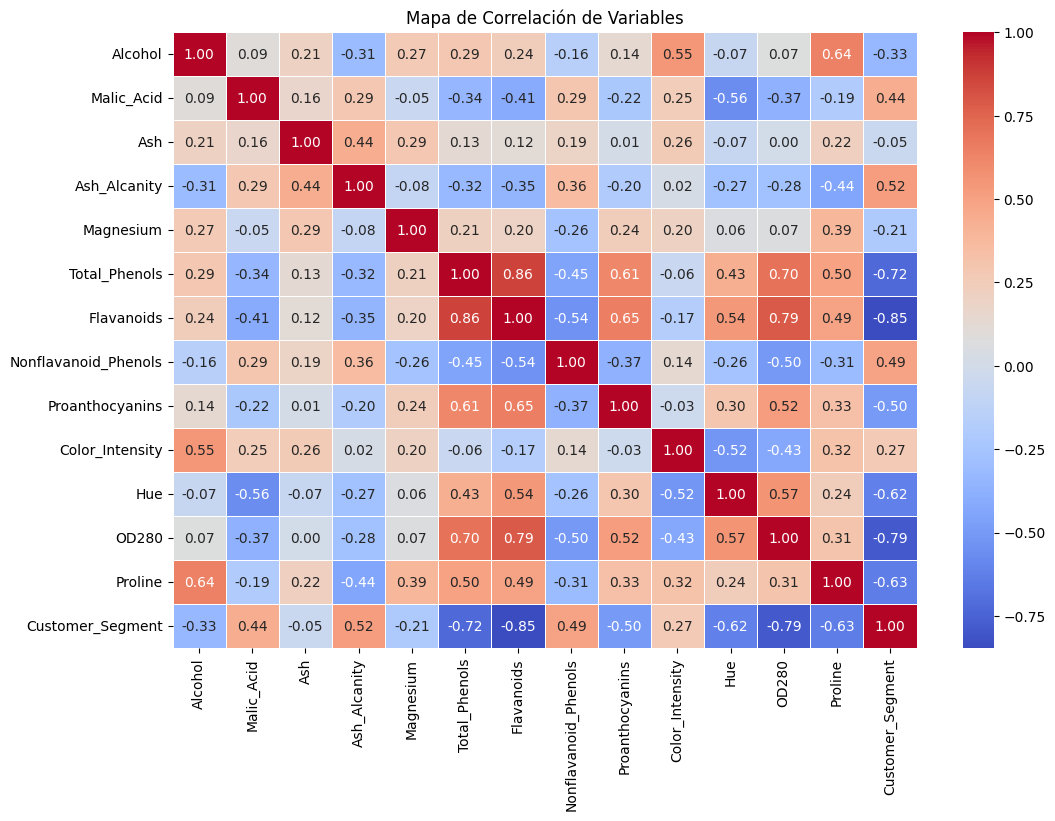


Se realiza el mapa de correlación para determinar como se relacionan las variables entre sí.
         En base a los resultados, se escogen dos variables predictoras que contengan alta correlacion con la variable dependiente:
         - Flavanoids (Flavanoides)
         - Proline (Prolina)



In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(datos.corr(), fmt=".2f", annot=True, cmap='coolwarm', linewidths=0.7)
plt.title('Mapa de Correlación de Variables')
plt.show()

print("""\nSe realiza el mapa de correlación para determinar como se relacionan las variables entre sí.
         En base a los resultados, se escogen dos variables predictoras que contengan alta correlacion con la variable dependiente:
         - Flavanoids (Flavanoides)
         - Proline (Prolina)
""")

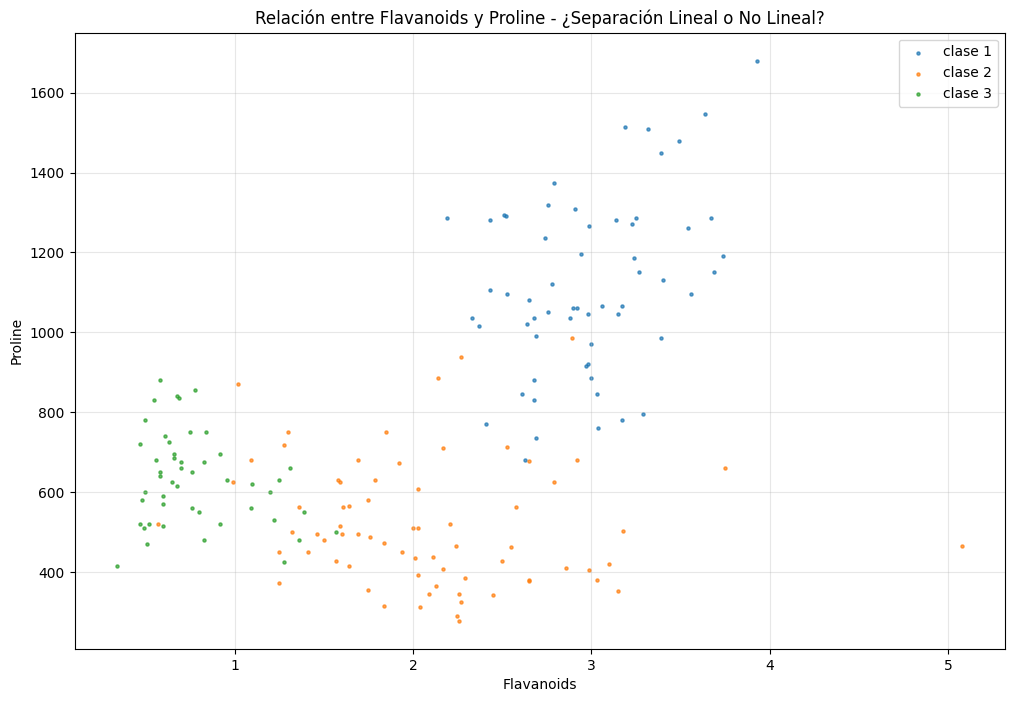


Se detecta que:
La clase 1 posee valores intermedios y altos de Prolina y valores dispersos de Flavonoides.
La clase 2 posee valores intermedios y bajos de Prolina y valores dispersos de Flavonoides
La clase 3 tiene valores intermedios y bajos de Prolina y valores bajos de Flavonoides.
Aunque entre la clase 1 y la clase 2 se puede sugerir una frontera lineal (Uso de LDA), 
entre la clase 2 y 3 extiste superposicion de los valores justificando el posible uso de QDA.
Esta visualización preliminar no determina cual modelo se debe usar debido a que solo se muestra la interacción de 2 variables.
Por lo cual, es recomendable el entrenamiento de los dos modelos debido a que con el uso de todas las variables se obtendrán otros resultados.



In [ ]:
plt.figure(figsize=(12,8))

#Primera columna correspondiente al eje X
X_var = 'Flavanoids'
#Segunda columna correspondiente al eje y
y_var = 'Proline'

#Dibujo de los valores por cada clase
for clase in datos['Customer_Segment'].unique():
  subset = datos[datos['Customer_Segment'] == clase]
  plt.scatter(subset[X_var], subset[y_var], label=f'clase {clase}', alpha=0.7, s=5)

#Etiquetas del grafico scatterplot
plt.xlabel(X_var)
plt.ylabel(y_var)
plt.title(f'Relación entre {X_var} y {y_var} - ¿Separación Lineal o No Lineal?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("""\nSe detecta que:
La clase 1 posee valores intermedios y altos de Prolina y valores dispersos de Flavonoides.
La clase 2 posee valores intermedios y bajos de Prolina y valores dispersos de Flavonoides
La clase 3 tiene valores intermedios y bajos de Prolina y valores bajos de Flavonoides.
Aunque entre la clase 1 y la clase 2 se puede sugerir una frontera lineal (Uso de LDA),
entre la clase 2 y 3 extiste superposicion de los valores justificando el posible uso de QDA.
Esta visualización preliminar no determina cual modelo se debe usar debido a que solo se muestra la interacción de 2 variables.
Por lo cual, es recomendable el entrenamiento de los dos modelos debido a que con el uso de todas las variables se obtendrán otros resultados.
""")

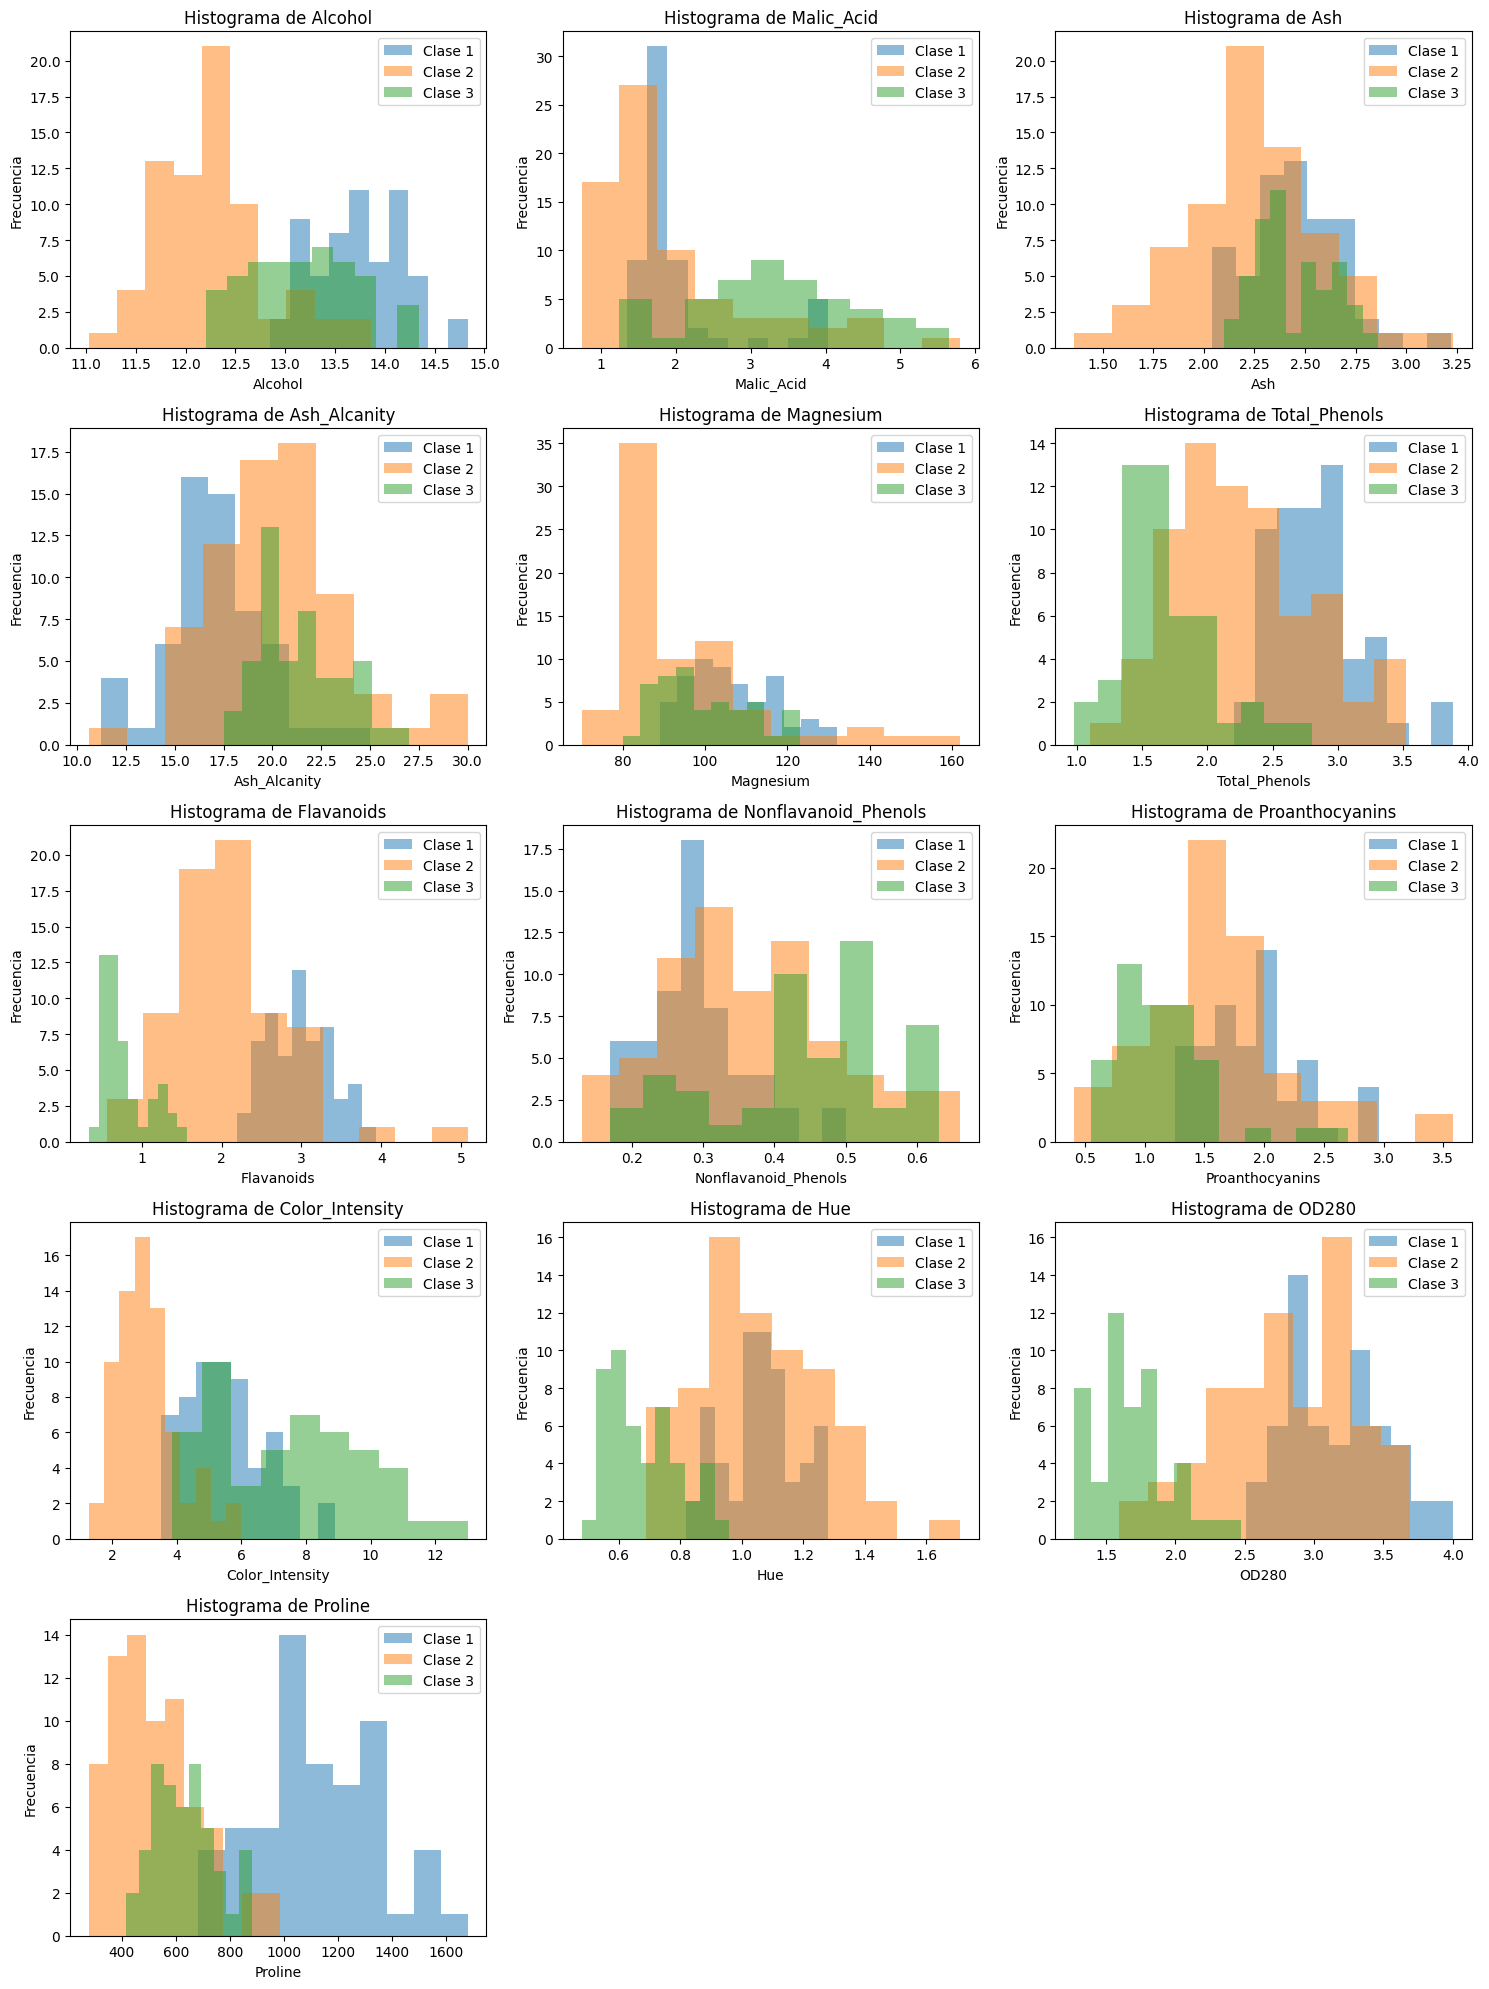


Aunque podemos observar que podemos hacer uso de los 2 modelos:
Analisis discriminante Lineal (LDA): Existen variables como Flavanoids y Total_Phenols muestran separación lineal.
Análisis Discriminante Cuadrático (QDA): Variables como Color_Intensity muestran distribuciones asimétricas, por lo cual, este modelo es válido para ser utilizado. 



In [ ]:
n_features = len(X.columns)
n_cols = 3  # Número de columnas for subplots
n_rows = (n_features + n_cols - 1) // n_cols # Cálculo de filas dinámicamente

plt.figure(figsize=(n_cols * 5, n_rows * 4)) #ancho y alto de la figura dinámico

# 1. HISTOGRAMAS de las variables
for i, col in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    for clase_label in y.unique(): # Realiza la iteracion sobre etiquetas de clase unicas y reales
        plt.hist(X[y == clase_label][col], alpha=0.5, label=f'Clase {clase_label}', bins=10)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.title(f'Histograma de {col}')
    plt.legend()
plt.tight_layout()
plt.show()

print("""\nAunque podemos observar que podemos hacer uso de los 2 modelos:
Analisis discriminante Lineal (LDA): Existen variables como Flavanoids y Total_Phenols muestran separación lineal.
Análisis Discriminante Cuadrático (QDA): Variables como Color_Intensity muestran distribuciones asimétricas, por lo cual, este modelo es válido para ser utilizado.
""")

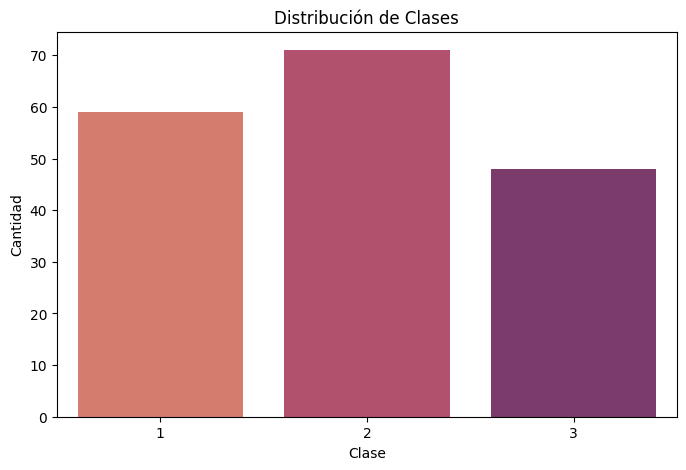


Distribucion de los valores en las 3 clases presentes en la variable dependiente "Customer_Segment"
Cumple la función de visualizar la ausencia de valores atípicos.



In [ ]:
#Distribución de clases
plt.figure(figsize=(8,5))
sns.countplot(x='Customer_Segment', data=datos, palette='flare')
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

print("""\nDistribucion de los valores en las 3 clases presentes en la variable dependiente "Customer_Segment"
Cumple la función de visualizar la ausencia de valores atípicos.
""")

##Preparación de los datos

In [ ]:
#Separación de datos de entrenamiento y datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22, stratify = y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Implementación de LDA


Parámetros utilizados en el modelo:
- solver=svd: svd son las siglas de Singular Value Decomposition y corresponde al resolvedor por defecto.
  Eficiente para muchas variables predictoras, 
  brinda mas estabilidad numérica debido a que no calcula de forma explícita la matriz de covarianza
- n_components=None: parámetro para definir la reduccion de datos, al estar en None 


Parámetros utilizados en métricas:
- average=weighted: uso de promedio ponderado para proporcionar métricas mas realistas.


Tiempo de entrenamiento: 0.001937 segundos
Accuracy: 0.9444
Precision (weighted): 0.9461
Recall (weighted): 0.9444
F1-Score (weighted): 0.9448

Reporte de Clasificación:
              precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.91      0.95      0.93        21
           3       0.93      0.93      0.93        15

    accuracy                           0.94        54
   macro avg       0.95      0.94      0.94        54


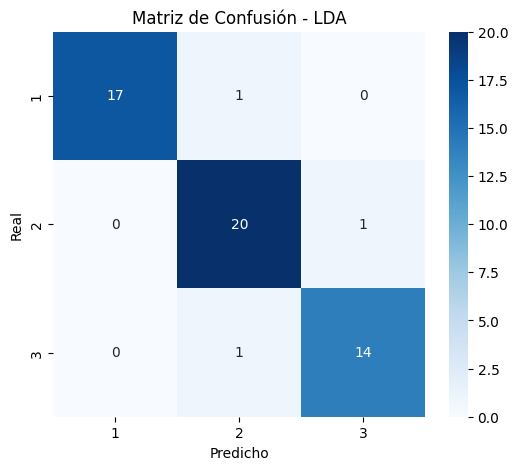


La mayor cantidad de datos se encuentran en la matriz principal y pocos datos fuera de ella.
Esto representa un comportamiento normal y encaja con los altos valores obtenidos en las métricas de rendimiento.



In [ ]:
lda = LinearDiscriminantAnalysis(solver='svd', n_components=None)

print("""\nParámetros utilizados en el modelo:
- solver=svd: svd son las siglas de Singular Value Decomposition y corresponde al resolvedor por defecto.
  Eficiente para muchas variables predictoras,
  brinda mas estabilidad numérica debido a que no calcula de forma explícita la matriz de covarianza
- n_components=None: parámetro para definir la reduccion de datos, al estar en None
""")

start_time = time.time()
lda.fit(X_train_scaled, y_train)
lda_time = time.time() - start_time
y_pred_lda = lda.predict(X_test_scaled)

cm_lda = confusion_matrix(y_test, y_pred_lda)
accuracy_lda = accuracy_score(y_test, y_pred_lda)
precision_lda = precision_score(y_test, y_pred_lda, average='weighted')
recall_lda = recall_score(y_test, y_pred_lda, average='weighted')
f1_lda = f1_score(y_test, y_pred_lda, average='weighted')


print("""\nParámetros utilizados en métricas:
- average=weighted: uso de promedio ponderado para proporcionar métricas mas realistas.
""")

print(f"\nTiempo de entrenamiento: {lda_time:.6f} segundos")
print(f"Accuracy: {accuracy_lda:.4f}")
print(f"Precision (weighted): {precision_lda:.4f}")
print(f"Recall (weighted): {recall_lda:.4f}")
print(f"F1-Score (weighted): {f1_lda:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lda))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(),
            yticklabels=y.unique())
plt.title('Matriz de Confusión - LDA')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

print("""\nLa mayor cantidad de datos se encuentran en la matriz principal y pocos datos fuera de ella.
Esto representa un comportamiento normal y encaja con los altos valores obtenidos en las métricas de rendimiento.
""")

## Implementación de QDA


Parámetros utilizados en el modelo:
- reg_param=0.0: parámetro de control de la regulaización del modelo, 
el valor 0.0 indica que no existe penalización en las matrices calculadas.
- store_covariance=True: cálculo y almacenamiento de matrices de covarianza por clase.


Parámetros utilizados en métricas:
- average=weighted: Igual a LDA, representa el uso de promedio ponderado para proporcionar métricas mas realistas.

Tiempo de entrenamiento: 0.002844 segundos
Accuracy: 0.9630
Precision (weighted): 0.9662
Recall (weighted): 0.9630
F1-Score (weighted): 0.9625

Reporte de Clasificación:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.91      1.00      0.95        21
           3       1.00      0.87      0.93        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



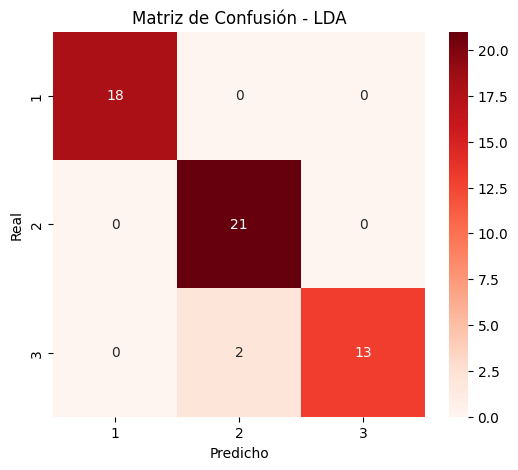


En QDA, se clasificaron correctamente los valores de las clases 1 y 2.
En la clase 3 hubo confusión ya que no se clasificaron correctamente los valores que correspondian a esa clase.
Se debe considerar que este algoritmo es ligeramente superior a LDA en este conjunto de datos



In [ ]:
qda = QuadraticDiscriminantAnalysis(reg_param=0.0, store_covariance=True)

print("""\nParámetros utilizados en el modelo:
- reg_param=0.0: parámetro de control de la regulaización del modelo,
el valor 0.0 indica que no existe penalización en las matrices calculadas.
- store_covariance=True: cálculo y almacenamiento de matrices de covarianza por clase.
""")

start_qda = time.time()
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
qda_time = time.time() - start_qda

y_pred_qda = qda.predict(X_test_scaled)

cm_qda = confusion_matrix(y_test, y_pred_qda)
accuracy_qda = accuracy_score(y_test, y_pred_qda)
precision_qda = precision_score(y_test, y_pred_qda, average='weighted')
recall_qda = recall_score(y_test, y_pred_qda, average='weighted')
f1_qda = f1_score(y_test, y_pred_qda, average='weighted')

print("""\nParámetros utilizados en métricas:
- average=weighted: Igual a LDA, representa el uso de promedio ponderado para proporcionar métricas mas realistas.
""")

print(f"Tiempo de entrenamiento: {qda_time:.6f} segundos")
print(f"Accuracy: {accuracy_qda:.4f}")
print(f"Precision (weighted): {precision_qda:.4f}")
print(f"Recall (weighted): {recall_qda:.4f}")
print(f"F1-Score (weighted): {f1_qda:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_qda))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Reds',
            xticklabels=y.unique(),
            yticklabels=y.unique())
plt.title('Matriz de Confusión - LDA')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

print("""\nEn QDA, se clasificaron correctamente los valores de las clases 1 y 2.
En la clase 3 hubo confusión ya que no se clasificaron correctamente los valores que correspondian a esa clase.
Se debe considerar que este algoritmo es ligeramente superior a LDA en este conjunto de datos
""")

## Comparación de modelos

In [ ]:
tabla_comparativa = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Tiempo (seg)'],
    'LDA': [accuracy_lda, precision_lda, recall_lda, f1_lda, lda_time],
    'QDA': [accuracy_qda, precision_qda, recall_qda, f1_qda, qda_time]
})

tabla_comparativa.head()





,Métrica,LDA,QDA
0,Accuracy,0.944444,0.962963
1,Precision,0.946128,0.966184
2,Recall,0.944444,0.962963
3,F1-Score,0.944826,0.962482
4,Tiempo (seg),0.019024,0.001993


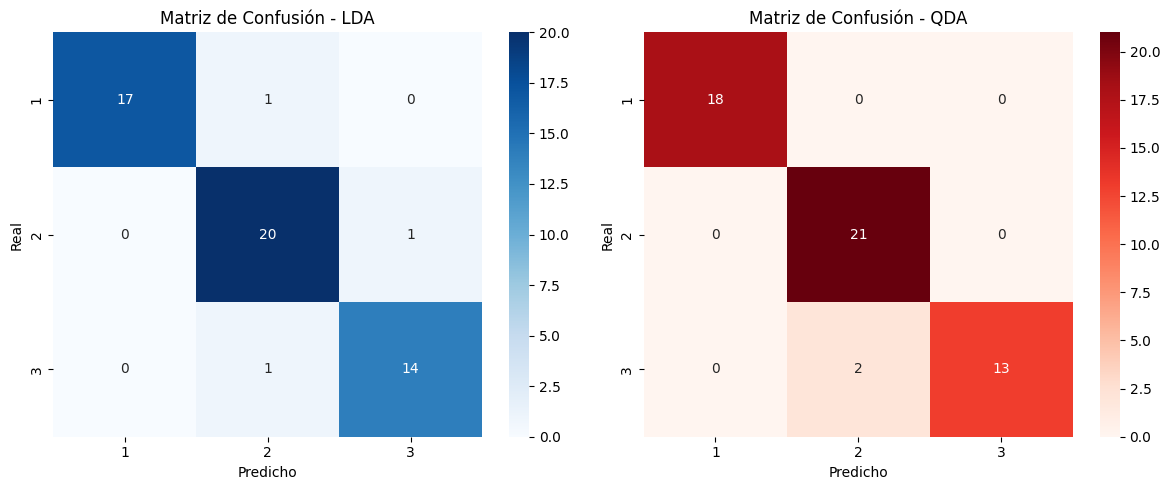


LDA es más rápido y estable
LDA asume que la matriz de covarianza es la misma para todas las clases.
Si el dataset es pequeño, LDA es más confiable.
QDA es más flexible pero requiere muestras más grandes para la estimación de las covarianzas.
Cuando las clases tienen dispersiones muy diferentes, QDA es superior.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(),
            yticklabels=y.unique(),
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - LDA')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Reds',
            xticklabels=y.unique(),
            yticklabels=y.unique(),
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - QDA')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()

print("""\nLDA es más rápido y estable
LDA asume que la matriz de covarianza es la misma para todas las clases.
Si el dataset es pequeño, LDA es más confiable.
QDA es más flexible pero requiere muestras más grandes para la estimación de las covarianzas.
Cuando las clases tienen dispersiones muy diferentes, QDA es superior.""")

## Fronteras de decisión

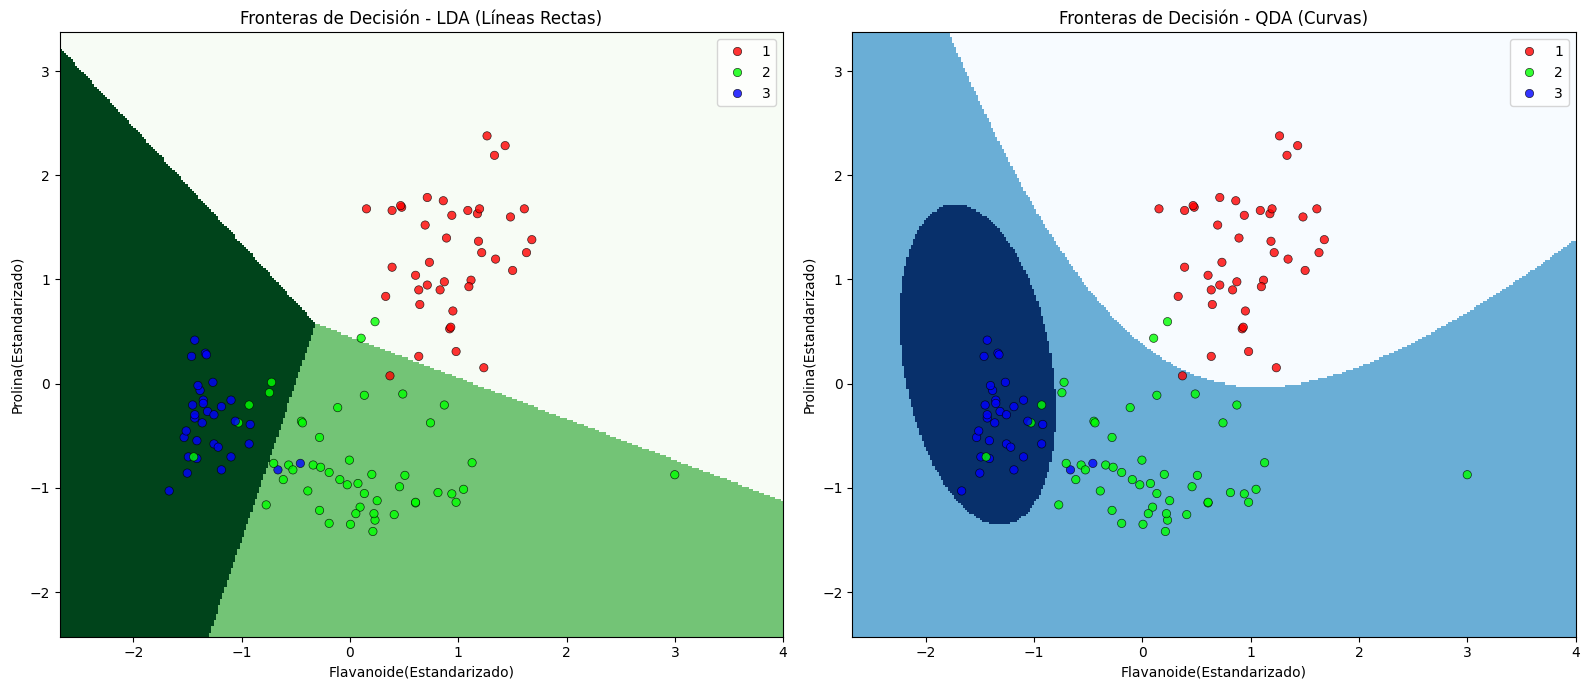


En los gráficos podemos observar que las fronteras capturan los datos en la clasificación correcta, 
obteniendo una ligera superioridad en el algoritmo QDA, esto tambien se ve reflejado en las metricas como Precision y Accuracy. 


In [ ]:
X_2d = datos[['Flavanoids','Proline']].values
y_2d = datos['Customer_Segment'].values

# Dividir y estandarizar solo para estas dos variables
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.3, random_state=22, stratify=y_2d)
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)

# Entrenar modelos simplificados
lda_2d = LinearDiscriminantAnalysis().fit(X_train_2d_scaled, y_train_2d)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_train_2d_scaled, y_train_2d)

# Crear la malla para graficar (Meshgrid)
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Configurar mapas de colores
cmap_bold = ['#FF0000', '#00FF00', '#0000FF']

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Graficar LDA
Z_lda = lda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lda = Z_lda.reshape(xx.shape)
ax[0].pcolormesh(xx, yy, Z_lda, cmap='Greens', shading='auto')
sns.scatterplot(x=X_train_2d_scaled[:, 0], y=X_train_2d_scaled[:, 1], hue=y_train_2d, palette=cmap_bold, alpha=0.8, ax=ax[0], edgecolor='k')
ax[0].set_title('Fronteras de Decisión - LDA (Líneas Rectas)')
ax[0].set_xlabel('Flavanoide(Estandarizado)')
ax[0].set_ylabel('Prolina(Estandarizado)')

# Graficar QDA
Z_qda = qda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_qda = Z_qda.reshape(xx.shape)
ax[1].pcolormesh(xx, yy, Z_qda, cmap='Blues', shading='auto')
sns.scatterplot(x=X_train_2d_scaled[:, 0], y=X_train_2d_scaled[:, 1], hue=y_train_2d, palette=cmap_bold, alpha=0.8, ax=ax[1], edgecolor='k')
ax[1].set_title('Fronteras de Decisión - QDA (Curvas)')
ax[1].set_xlabel('Flavanoide(Estandarizado)')
ax[1].set_ylabel('Prolina(Estandarizado)')

plt.tight_layout()
plt.show()

print("""\nEn los gráficos podemos observar que las fronteras capturan los datos en la clasificación correcta,
obteniendo una ligera superioridad en el algoritmo QDA, esto tambien se ve reflejado en las metricas como Precision y Accuracy. """)

## Conclusiones



1.   LDA es un algoritmo más estable y sencillo, minimiza el riesgo de sobreajuste en conjuntos de datos pequeños especialmente y busca tener proyección mas simplificada.
2.   QDA es mas flexible y adaptable, debido a que establece fronteras curvas se moldea a la dispersión que presenta cada clase, rescatando datos con clasificación mas compleja que son imposibles de detectar con LDA.
1.   El supuesto estadistico en QDA que indica que las clases no comparten la misma matriz de covarianza permitió que, en este conjunto de datos, este algoritmo obtenga mejor rendimiento en la evaluación las métricas
2.   Como redacté tambien en el informe LDA es un algoritmo adecuado para clasificacion en diagnóstico médico (Detección de tumores malignos y benignos) y análisis financiero (Predcción de quiebra).
1.   El algoritmo QDA es adecuado para problemas como el que se presenta en este conjunto de datos (control de calidad) donde los clases tienen dispersiones o comportamientos distintos entre clases y existe suficiente data para aportar a esto algoritmo complejo.
2.   Ambos algoritmos demostraron eficiencia computacional (diferencias de milisegundos) y evidencian sus ventajas:
LDA (distribución homogénea de los errores entre las 3 clases) y QDA (Mejor comprensión y captura de las dispersiones de clases).






